# 01. Análise Exploratória (EDA)

**Objetivo de negócio:** estimar o gasto mensal esperado de cada cliente a partir do seu perfil e comportamento, para apoiar a priorização de ações de CRM, o dimensionamento de metas de receita e a identificação de clientes gastando abaixo do esperado para o perfil deles.

**Suposição assumida:** a base não traz um timestamp explícito, então assumimos que as features descrevem o estado do cliente no momento em que a previsão seria feita, e que `gasto_mensal` é o gasto do período seguinte. Essa suposição não dá para testar diretamente com os dados disponíveis, já que não existe um dicionário oficial da fonte confirmando isso (o `DATA_DICTIONARY.md` detalha cada variável e o que precisaria ser validado antes de usar o modelo em produção).

In [3]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src import data_prep, modeling, evaluation, interpretability, visualization

visualization.set_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"

## 1. Carregar e entender a estrutura dos dados

In [ ]:
df_raw = data_prep.load_raw_data()
df_diag = data_prep.clean_data(df_raw, False, False)

target = data_prep.TARGET
features = [c for c in df_diag.columns if c != target]

print("Formato (bruto, colunas de índice removidas):", df_diag.shape)
print("Features:", features)
df_diag.head()

Formato (bruto, colunas de índice removidas): (2200, 10)
Features: ['idade', 'renda', 'tempo_cliente', 'frequencia', 'reclamacoes', 'engajamento', 'dias_sem_comprar', 'desconto', 'ticket']


,idade,renda,tempo_cliente,frequencia,reclamacoes,engajamento,dias_sem_comprar,desconto,ticket,gasto_mensal
0,35.854694,4379.599275,5.100554,8.366152,2,99.646007,9.417171,11.941011,174.279971,2659.349831
1,25.207447,5405.197007,6.223224,9.449941,3,99.483219,23.085392,19.219608,223.815191,3546.329801
2,38.940057,4299.615577,2.903725,7.726809,2,98.699483,7.986427,16.548449,171.451762,3032.314364
3,60.551034,5995.765751,5.490279,15.457916,1,98.536292,23.180922,18.463324,109.668871,3941.132663
4,35.963310,4325.959318,3.231117,11.895505,2,98.339928,30.608135,10.958427,207.152144,2390.319692


In [12]:
print("Tipos de dado:")
print(df_diag.dtypes)
print()
print("Valores ausentes por coluna:")
print(df_diag.isnull().sum())
print()
print("Linhas duplicadas:", df_diag.duplicated().sum())
print()
print("Valores negativos por coluna numérica:")
print((df_diag.select_dtypes(include=[np.number]) < 0).sum())

Tipos de dado:
idade               float64
renda               float64
tempo_cliente       float64
frequencia          float64
reclamacoes           int64
engajamento         float64
dias_sem_comprar    float64
desconto            float64
ticket              float64
gasto_mensal        float64
dtype: object

Valores ausentes por coluna:
idade               0
renda               0
tempo_cliente       0
frequencia          0
reclamacoes         0
engajamento         0
dias_sem_comprar    0
desconto            0
ticket              0
gasto_mensal        0
dtype: int64

Linhas duplicadas: 0

Valores negativos por coluna numérica:
idade               0
renda               0
tempo_cliente       0
frequencia          0
reclamacoes         0
engajamento         0
dias_sem_comprar    0
desconto            0
ticket              0
gasto_mensal        0
dtype: int64


* A base está limpa: sem valores nulos, duplicatas ou negativos.
* A variável `idade` tem valores abaixo de 18 anos, implausíveis para clientes com histórico de compras. Investigamos e tratamos isso na próxima seção, com um teste de sensibilidade, em vez de só documentar o problema.

In [13]:
n_idade_invalida = data_prep.idade_invalida_mask(df_diag).sum()
print(f"Idades implausíveis (< {data_prep.IDADE_MINIMA_VALIDA} anos): {n_idade_invalida} de {len(df_diag)} linhas ({n_idade_invalida/len(df_diag):.1%})")
df_diag.loc[data_prep.idade_invalida_mask(df_diag), "idade"].describe()

Idades implausíveis (< 18 anos): 39 de 2200 linhas (1.8%)


count    39.000000
mean     13.745812
std       3.579786
min       3.178691
25%      11.932132
50%      14.263959
75%      16.092154
max      17.972186
Name: idade, dtype: float64

## 2. Tratamento de `idade` implausível: decisão baseada em teste de sensibilidade

Esses 39 registros são um problema de qualidade de dado: uma idade abaixo de 18 anos é implausível para um cliente com histórico de compras. Antes de decidir o que fazer com eles, testamos duas perguntas:

1. **A remoção muda a performance do modelo?** Comparamos o RMSE de teste com e sem essas linhas, em 10 splits diferentes (`random_state` de 0 a 9), para não tirar conclusão de uma única divisão de dados por sorte.
2. **Essas linhas são difíceis de prever?** Se fossem, poderíamos suspeitar que representam algum outro problema de qualidade correlacionado. Comparamos o erro absoluto médio dessas 39 linhas com o resto da base, usando um modelo treinado com a base inteira.

In [14]:
def avg_rmse_over_seeds(df_scenario, seeds=range(10)):
    rows = []
    for s in seeds:
        X, y = data_prep.get_feature_target(df_scenario, target)
        X_train, X_test, y_train, y_test = data_prep.make_split(X, y, random_state=s)
        ridge = modeling.get_models()["Ridge"]
        ridge.fit(X_train, y_train)
        rows.append(evaluation.regression_metrics(y_test, ridge.predict(X_test))["RMSE"])
    return np.array(rows)

rmse_com = avg_rmse_over_seeds(df_diag)
df_sem_idade_ruim = df_diag.loc[~data_prep.idade_invalida_mask(df_diag)].reset_index(drop=True)
rmse_sem = avg_rmse_over_seeds(df_sem_idade_ruim)

print(f"RMSE médio (Ridge, 10 seeds) COM idade < 18: {rmse_com.mean():.1f} +- {rmse_com.std():.1f}")
print(f"RMSE médio (Ridge, 10 seeds) SEM idade < 18: {rmse_sem.mean():.1f} +- {rmse_sem.std():.1f}")

# Essas 39 linhas são "difíceis" de prever? (erro no modelo treinado com tudo)
X_full, y_full = data_prep.get_feature_target(df_diag, target)
X_train, X_test, y_train, y_test = data_prep.make_split(X_full, y_full, random_state=42)
ridge_full = modeling.get_models()["Ridge"]
ridge_full.fit(X_train, y_train)
resid_abs = np.abs(y_full.values - ridge_full.predict(X_full))
mask_bad_age = data_prep.idade_invalida_mask(df_diag).values

print(f"\nErro absoluto médio nas linhas com idade < 18: R$ {resid_abs[mask_bad_age].mean():.1f} (n={mask_bad_age.sum()})")
print(f"Erro absoluto médio no restante da base:        R$ {resid_abs[~mask_bad_age].mean():.1f} (n={(~mask_bad_age).sum()})")

RMSE médio (Ridge, 10 seeds) COM idade < 18: 365.4 +- 6.4
RMSE médio (Ridge, 10 seeds) SEM idade < 18: 370.1 +- 8.6

Erro absoluto médio nas linhas com idade < 18: R$ 230.2 (n=39)
Erro absoluto médio no restante da base:        R$ 284.7 (n=2161)


O efeito médio de remover as 39 linhas é neutro, talvez levemente negativo no RMSE, dentro do ruído entre seeds. E o erro absoluto médio dessas linhas é menor, não maior, que o do restante da base, ou seja, elas não são "casos difíceis" que o modelo erra mais. Isso mostra que a decisão de remover não é motivada por ganho de performance, já que não há ganho consistente. É uma questão de validade do dado: uma idade abaixo de 18 anos para um cliente com histórico de compras é implausível, provavelmente um erro de captura na fonte, e não deveria entrar no treino nem na avaliação do modelo. Mesmo que o efeito prático seja pequeno hoje, manter um dado inválido só porque "não faz diferença agora" é um risco caso o problema se agrave em cargas futuras de dados.

A partir daqui, `data_prep.clean_data()` (com o parâmetro default `filtrar_idade_invalida=True`) é a limpeza oficial usada em todo o pipeline, inclusive por `run_all.py` e pelos notebooks 02 a 06.

### `tempo_cliente` inconsistente com a idade

Ainda olhando a relação entre `idade` e as outras variáveis, vale checar mais uma coisa: em algumas linhas, `tempo_cliente` (antiguidade do cliente, em anos) é maior do que `idade - 18`, ou seja, o cliente teria começado a comprar antes de completar 18 anos (a mesma idade mínima assumida no filtro anterior). Isso já sem contar as linhas de idade implausível, que foram tratadas acima.

In [15]:
mask_tempo_invalido = data_prep.tempo_cliente_invalido_mask(df_sem_idade_ruim)
n_tempo_invalido = mask_tempo_invalido.sum()
print(f"Linhas com tempo_cliente > idade - {data_prep.IDADE_MINIMA_INICIO_RELACIONAMENTO}: {n_tempo_invalido} de {len(df_sem_idade_ruim)} linhas ({n_tempo_invalido/len(df_sem_idade_ruim):.1%})")
df_sem_idade_ruim.loc[mask_tempo_invalido, ["idade", "tempo_cliente"]].describe()

Linhas com tempo_cliente > idade - 18: 89 de 2161 linhas (4.1%)


,idade,tempo_cliente
count,89.000000,89.000000
mean,22.937786,7.386284
std,2.943565,3.387712
min,18.105820,0.869747
25%,20.701917,4.580914
50%,22.135017,7.242608
75%,24.980455,9.542282
max,31.823232,17.600139


Aplicamos o mesmo raciocínio usado para a idade: será que remover essas linhas muda a performance do modelo, e será que elas são difíceis de prever?

In [16]:
df_sem_tempo_invalido = df_sem_idade_ruim.loc[~mask_tempo_invalido].reset_index(drop=True)
rmse_sem_ambos = avg_rmse_over_seeds(df_sem_tempo_invalido)

print(f"RMSE médio (Ridge, 10 seeds), só sem idade implausível: {rmse_sem.mean():.1f} +- {rmse_sem.std():.1f}")
print(f"RMSE médio (Ridge, 10 seeds), sem idade implausível e sem tempo_cliente inconsistente: {rmse_sem_ambos.mean():.1f} +- {rmse_sem_ambos.std():.1f}")

X_full2, y_full2 = data_prep.get_feature_target(df_sem_idade_ruim, target)
X_train2, X_test2, y_train2, y_test2 = data_prep.make_split(X_full2, y_full2, random_state=42)
ridge_full2 = modeling.get_models()["Ridge"]
ridge_full2.fit(X_train2, y_train2)
resid_abs2 = np.abs(y_full2.values - ridge_full2.predict(X_full2))
mask_tempo_arr = mask_tempo_invalido.values

print(f"\nErro absoluto médio nas linhas com tempo_cliente inconsistente: R$ {resid_abs2[mask_tempo_arr].mean():.1f} (n={mask_tempo_arr.sum()})")
print(f"Erro absoluto médio no restante da base:                        R$ {resid_abs2[~mask_tempo_arr].mean():.1f} (n={(~mask_tempo_arr).sum()})")

RMSE médio (Ridge, 10 seeds), só sem idade implausível: 370.1 +- 8.6
RMSE médio (Ridge, 10 seeds), sem idade implausível e sem tempo_cliente inconsistente: 362.1 +- 10.3

Erro absoluto médio nas linhas com tempo_cliente inconsistente: R$ 263.3 (n=89)
Erro absoluto médio no restante da base:                        R$ 285.4 (n=2072)


O efeito no RMSE aqui é maior do que vimos com a idade: a média cai de forma mais consistente entre os seeds. Mas, assim como na idade, o erro absoluto médio dessas linhas é menor que o do restante da base, não maior. Elas não são casos difíceis, o modelo já acerta bem nelas. Isso importa porque mostra que a queda no RMSE não vem de tirar ruído que o modelo não conseguia prever, é um efeito colateral de mudar um pouco a composição da base de teste ao remover essas linhas. A decisão de remover segue o mesmo critério usado para a idade: validade do dado (um cliente não poderia ter começado a comprar antes dos 18 anos, pela mesma suposição já assumida acima), não ganho de performance.

A partir daqui, `data_prep.clean_data()` (com os dois filtros ativos por padrão, `filtrar_idade_invalida=True` e `filtrar_tempo_cliente_invalido=True`) é a limpeza oficial usada em todo o pipeline, inclusive por `run_all.py` e pelos notebooks 02 a 06.

In [17]:
df = data_prep.clean_data(df_raw)  # default: remove Unnamed + idade < 18 + tempo_cliente inconsistente
print("Formato após limpeza oficial (idade implausível e tempo_cliente inconsistente removidos):", df.shape)
df.head()

Formato após limpeza oficial (idade implausível e tempo_cliente inconsistente removidos): (2072, 10)


,idade,renda,tempo_cliente,frequencia,reclamacoes,engajamento,dias_sem_comprar,desconto,ticket,gasto_mensal
0,35.854694,4379.599275,5.100554,8.366152,2,99.646007,9.417171,11.941011,174.279971,2659.349831
1,25.207447,5405.197007,6.223224,9.449941,3,99.483219,23.085392,19.219608,223.815191,3546.329801
2,38.940057,4299.615577,2.903725,7.726809,2,98.699483,7.986427,16.548449,171.451762,3032.314364
3,60.551034,5995.765751,5.490279,15.457916,1,98.536292,23.180922,18.463324,109.668871,3941.132663
4,35.963310,4325.959318,3.231117,11.895505,2,98.339928,30.608135,10.958427,207.152144,2390.319692


## 3. Entender a target

In [18]:
df[target].describe()

count    2072.000000
mean     2383.935119
std       553.626244
min       601.547741
25%      1992.775122
50%      2381.009877
75%      2740.027713
max      4435.056696
Name: gasto_mensal, dtype: float64

## 4. Inspecionar distribuição da target

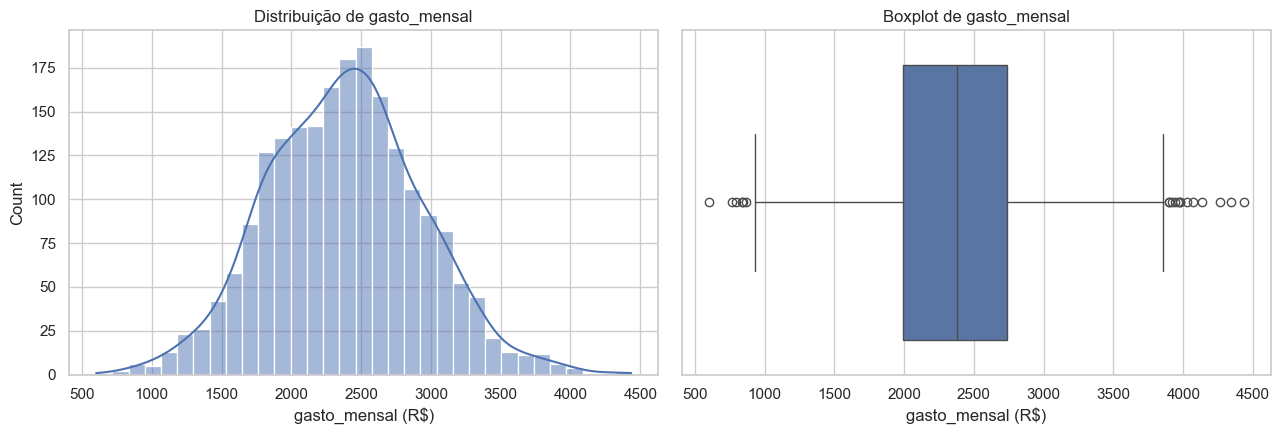

Assimetria (skew): 0.126
Curtose (excesso): 0.107


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
visualization.plot_target_distribution(df[target], axes[0], axes[1], label=target)
plt.tight_layout()
plt.show()

print(f"Assimetria (skew): {stats.skew(df[target]):.3f}")
print(f"Curtose (excesso): {stats.kurtosis(df[target]):.3f}")

O gráfico mostra uma distribuição praticamente simétrica, sem caudas longas nem concentração de valores extremos. Por isso, a variável não parece precisar de nenhuma transformação neste momento.

In [20]:
q1, q3 = df[target].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(df[target] < lower) | (df[target] > upper)]
print(f"Limites IQR: [{lower:.1f}, {upper:.1f}]")
print(f"Outliers pela regra 1.5xIQR: {len(outliers)} ({len(outliers)/len(df):.1%} da base)")

Limites IQR: [871.9, 3860.9]
Outliers pela regra 1.5xIQR: 19 (0.9% da base)


A regra do IQR encontrou poucos valores extremos na target. Vamos manter esses casos por enquanto, já que podem representar comportamentos reais de clientes.

## 5. EDA univariada de todas as features

Além da distribuição da target, olhamos aqui a distribuição de cada uma das 9 features individualmente (histograma, boxplot e checagem de outliers), e não só a correlação agregada delas com a target.

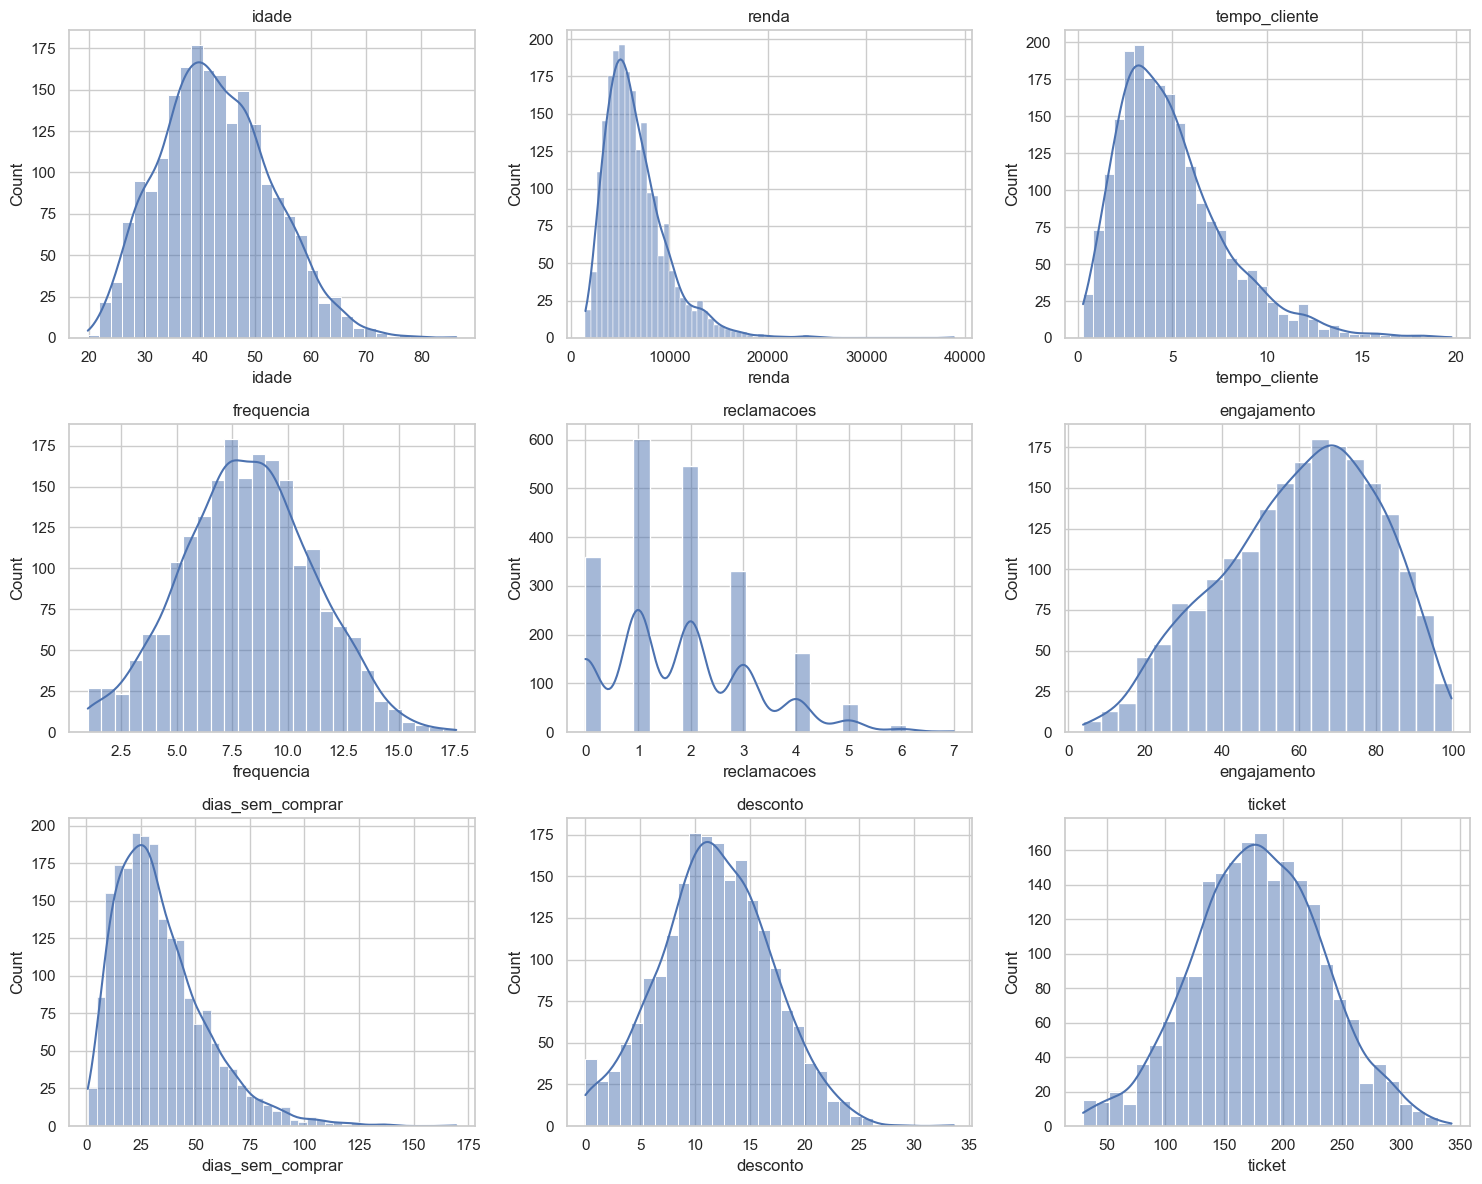

,count,mean,std,min,25%,50%,75%,max
idade,2072.0,42.914028,9.991856,19.771861,35.796907,42.083073,49.461231,86.284064
renda,2072.0,6603.023387,3235.514044,1474.738971,4394.438880,5926.907568,8061.767428,38873.133236
tempo_cliente,2072.0,4.969220,2.893681,0.288139,2.892207,4.391761,6.374112,19.738309
frequencia,2072.0,8.180114,2.958424,1.000000,6.199189,8.182668,10.145507,17.600729
reclamacoes,2072.0,1.797780,1.347113,0.000000,1.000000,2.000000,3.000000,7.000000
engajamento,2072.0,60.308720,20.262136,3.878413,46.016224,62.269191,75.982421,99.646007
dias_sem_comprar,2072.0,33.830331,20.961638,0.674611,18.604500,29.418926,44.240707,169.580007
desconto,2072.0,11.826318,5.077365,0.000000,8.499562,11.759171,15.246629,33.634604
ticket,2072.0,178.769153,54.943951,30.000000,141.533227,178.320934,215.265789,343.113532


In [21]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

df[features].describe().T

In [22]:
rows = []
for col in features:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    rows.append({"feature": col, "limite_inferior": lower, "limite_superior": upper,
                 "n_outliers_iqr": n_out, "pct_outliers": n_out / len(df)})
outlier_summary = pd.DataFrame(rows).sort_values("pct_outliers", ascending=False)
outlier_summary

,feature,limite_inferior,limite_superior,n_outliers_iqr,pct_outliers
1,renda,-1106.553942,13562.760251,78,0.037645
2,tempo_cliente,-2.330650,11.596969,75,0.036197
6,dias_sem_comprar,-19.849810,82.695018,64,0.030888
0,idade,15.300423,69.957715,14,0.006757
8,ticket,30.934384,325.864632,12,0.005792
7,desconto,-1.621040,25.367230,7,0.003378
3,frequencia,0.279713,16.064983,6,0.002896
4,reclamacoes,-2.000000,6.000000,3,0.001448
5,engajamento,1.066928,120.931716,0,0.000000


* `renda` é a feature com mais outliers pela regra do IQR (poucos % da base), com uma cauda direita longa: o valor máximo chega a ser várias vezes o percentil 75. Isso é coerente com uma distribuição de renda real, em que poucos clientes têm renda muito alta, e não tratamos como erro. São valores plausíveis de clientes de alto poder aquisitivo, diferente do que vimos com `idade`.
* `engajamento` fica limitado a uma faixa de score, não ultrapassa 100, e não tem outliers relevantes.
* Testamos separadamente (notebook 03, seção de experimentos) se aplicar `log1p` em `renda` melhora os modelos lineares. O resultado foi negativo, piora o RMSE de forma consistente, então mantivemos a variável na escala original.

## 6. Correlações e colinearidade

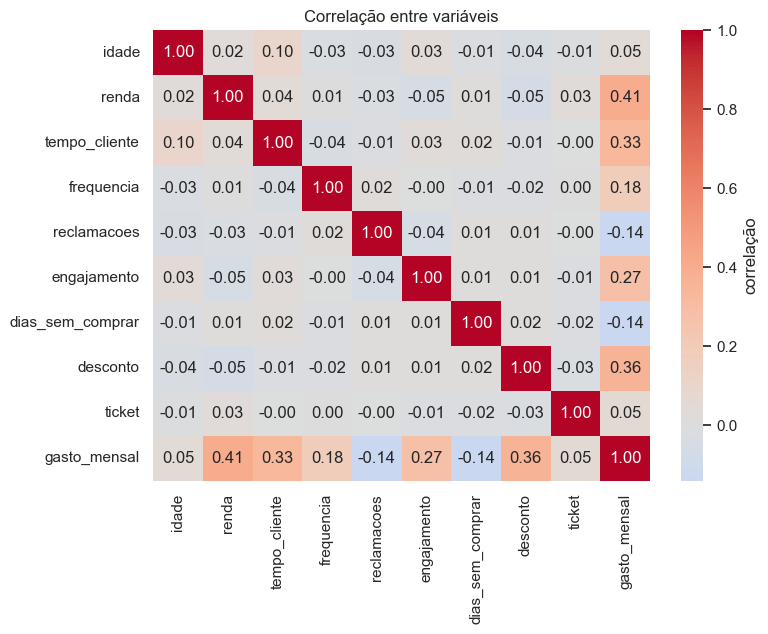

,correlação com gasto_mensal
renda,0.405269
desconto,0.362374
tempo_cliente,0.332364
engajamento,0.274127
frequencia,0.179562
dias_sem_comprar,-0.141310
reclamacoes,-0.137049
ticket,0.050606
idade,0.047874


In [23]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar_kws={"label": "correlação"})
ax.set_title("Correlação entre variáveis")
plt.tight_layout()
plt.show()

corr[target].drop(target).sort_values(key=np.abs, ascending=False).to_frame("correlação com gasto_mensal")

In [24]:
# VIF (Variance Inflation Factor) aproximado, feature a feature, para
# checar colinearidade de forma mais rigorosa do que só olhar o heatmap.
from sklearn.linear_model import LinearRegression

vif_rows = []
for col in features:
    y_aux = df[col]
    X_aux = df[features].drop(columns=[col])
    r2 = LinearRegression().fit(X_aux, y_aux).score(X_aux, y_aux)
    vif = 1 / (1 - r2) if r2 < 0.999 else np.inf
    vif_rows.append({"feature": col, "R2_auxiliar": r2, "VIF": vif})
pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)

,feature,R2_auxiliar,VIF
0,idade,0.014911,1.015137
2,tempo_cliente,0.014865,1.015090
1,renda,0.009577,1.009670
5,engajamento,0.007018,1.007067
7,desconto,0.006171,1.006210
4,reclamacoes,0.004683,1.004705
3,frequencia,0.003628,1.003641
8,ticket,0.002185,1.002190
6,dias_sem_comprar,0.002123,1.002127


* As correlações com a target são moderadas, com `renda`, `desconto`, `tempo_cliente` e `engajamento` mais relacionados ao `gasto_mensal`.
* O VIF de todas as features fica muito próximo de 1,0, o que confirma, não só visualmente mas de forma mais rigorosa, que não há colinearidade relevante entre elas. Isso também é um bom sinal contra vazamento de dados, já que nenhuma feature é combinação linear de outra.

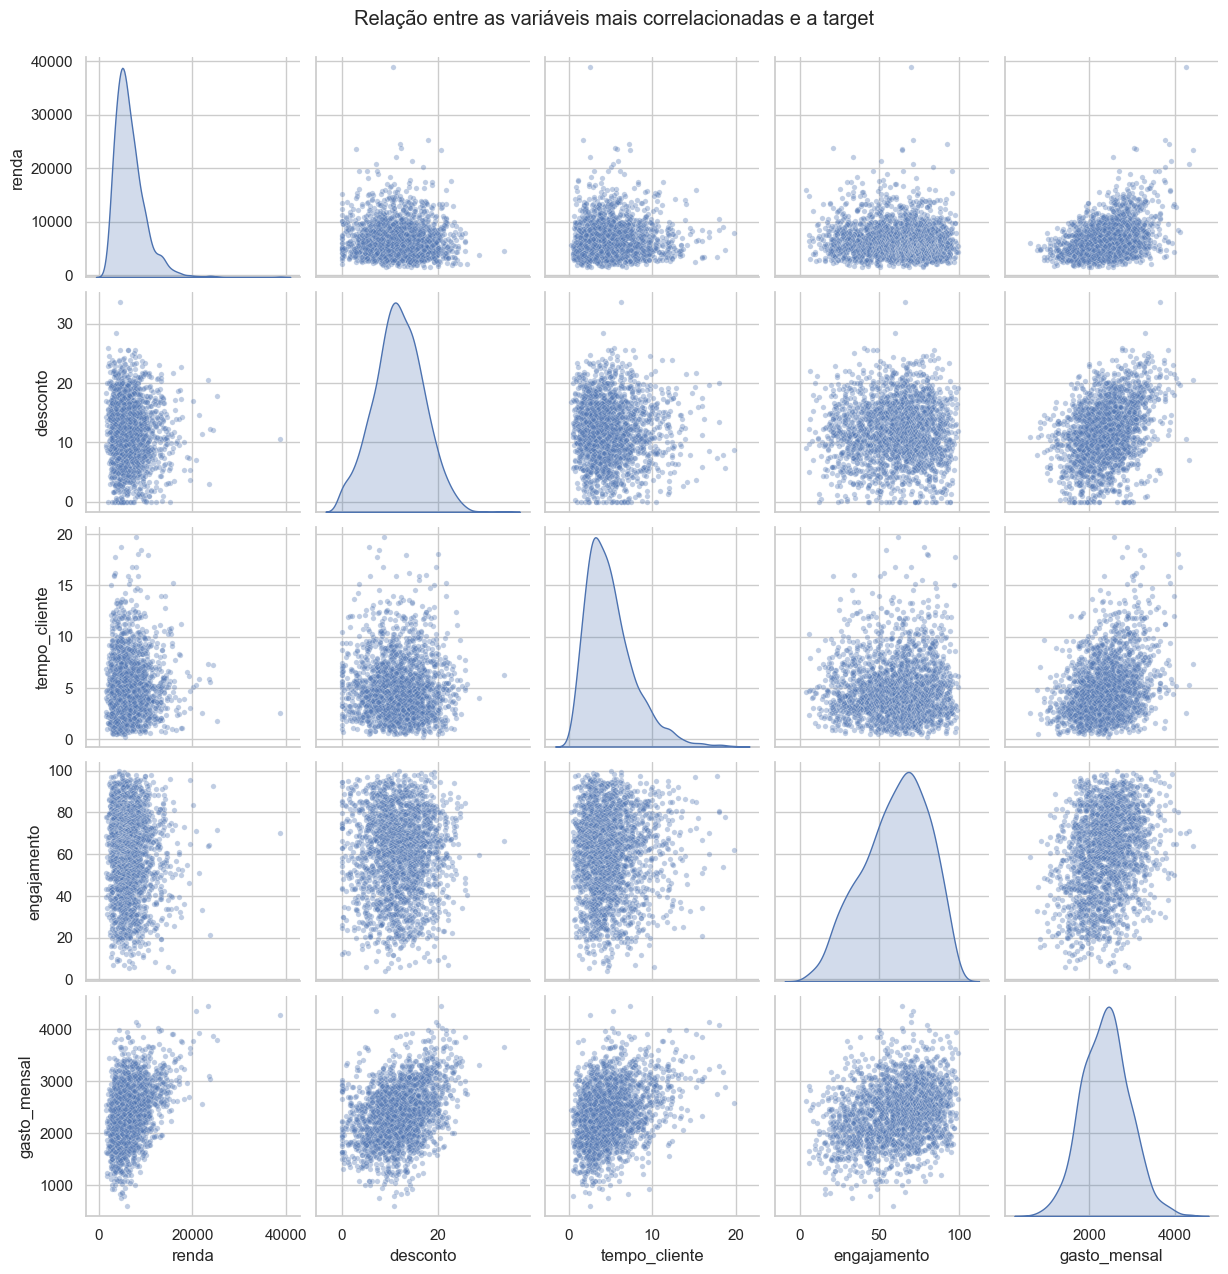

In [25]:
pair_cols = ["renda", "desconto", "tempo_cliente", "engajamento", target]
g = sns.pairplot(df[pair_cols], diag_kind="kde", plot_kws={"alpha": 0.35, "s": 15})
g.fig.suptitle("Relação entre as variáveis mais correlacionadas e a target", y=1.02)
plt.show()

## Saída desta etapa

In [26]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED_DIR / "dataset_limpo.csv", index=False)
print("Salvo em:", PROCESSED_DIR / "dataset_limpo.csv")
print("Linhas removidas por idade implausível:", n_idade_invalida)
print("Linhas removidas por tempo_cliente inconsistente com a idade:", n_tempo_invalido)

Salvo em: d:\mary-\Downloads\squad ds\squad-data-science\Case 3\data\processed\dataset_limpo.csv
Linhas removidas por idade implausível: 39
Linhas removidas por tempo_cliente inconsistente com a idade: 89
